**Análise exploratória do dataset**

In [ ]:
pip install autoviz

#Entendimento dos dados


Imported v0.1.905. Please call AutoViz in this sequence:
    AV = AutoViz_Class()
    %matplotlib inline
    dfte = AV.AutoViz(filename, sep=',', depVar='', dfte=None, header=0, verbose=1, lowess=False,
               chart_format='svg',max_rows_analyzed=150000,max_cols_analyzed=30, save_plot_dir=None)
Shape of your Data Set loaded: (704, 22)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  0
    Number of Integer-Categorical Columns =  1
    Number of String-Categorical Columns =  4
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  5
    Number of Numeric-Boolean Columns =  10
    Number of Discrete String Columns =  0
    Number of NLP String Columns =  0
    Number of

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
id,int64,0.000000,100,1.000000,704.000000,Possible ID column: drop before modeling step.
A1_Score,int64,0.000000,0,0.000000,1.000000,No issue
A2_Score,int64,0.000000,0,0.000000,1.000000,No issue
A3_Score,int64,0.000000,0,0.000000,1.000000,No issue
A4_Score,int64,0.000000,0,0.000000,1.000000,No issue
A5_Score,int64,0.000000,0,0.000000,1.000000,No issue
A6_Score,int64,0.000000,0,0.000000,1.000000,No issue
A7_Score,int64,0.000000,0,0.000000,1.000000,No issue
A8_Score,int64,0.000000,0,0.000000,1.000000,No issue
A9_Score,int64,0.000000,0,0.000000,1.000000,No issue


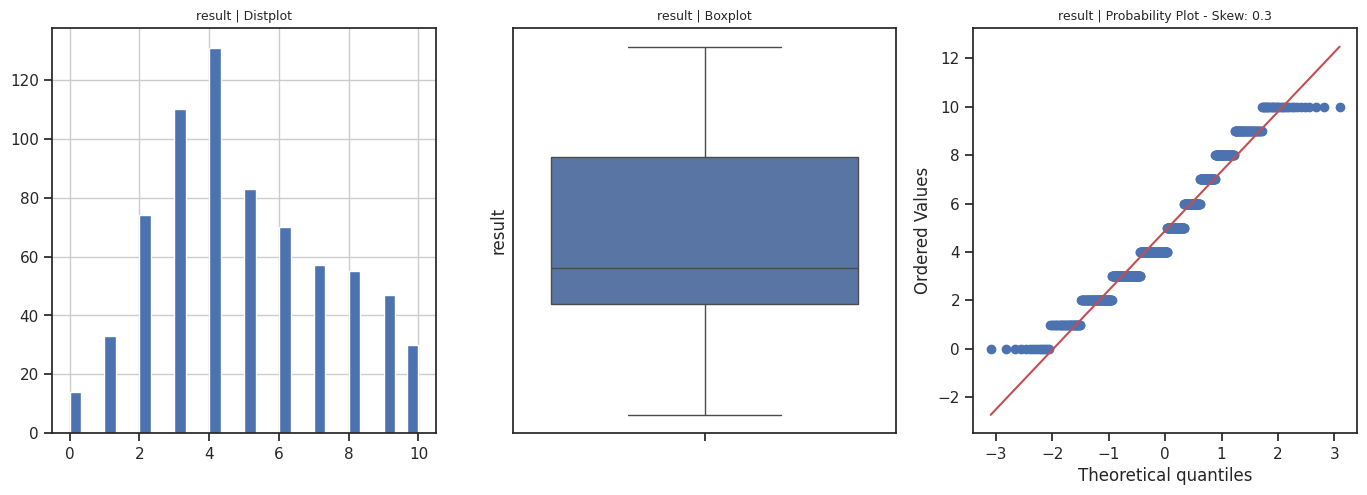

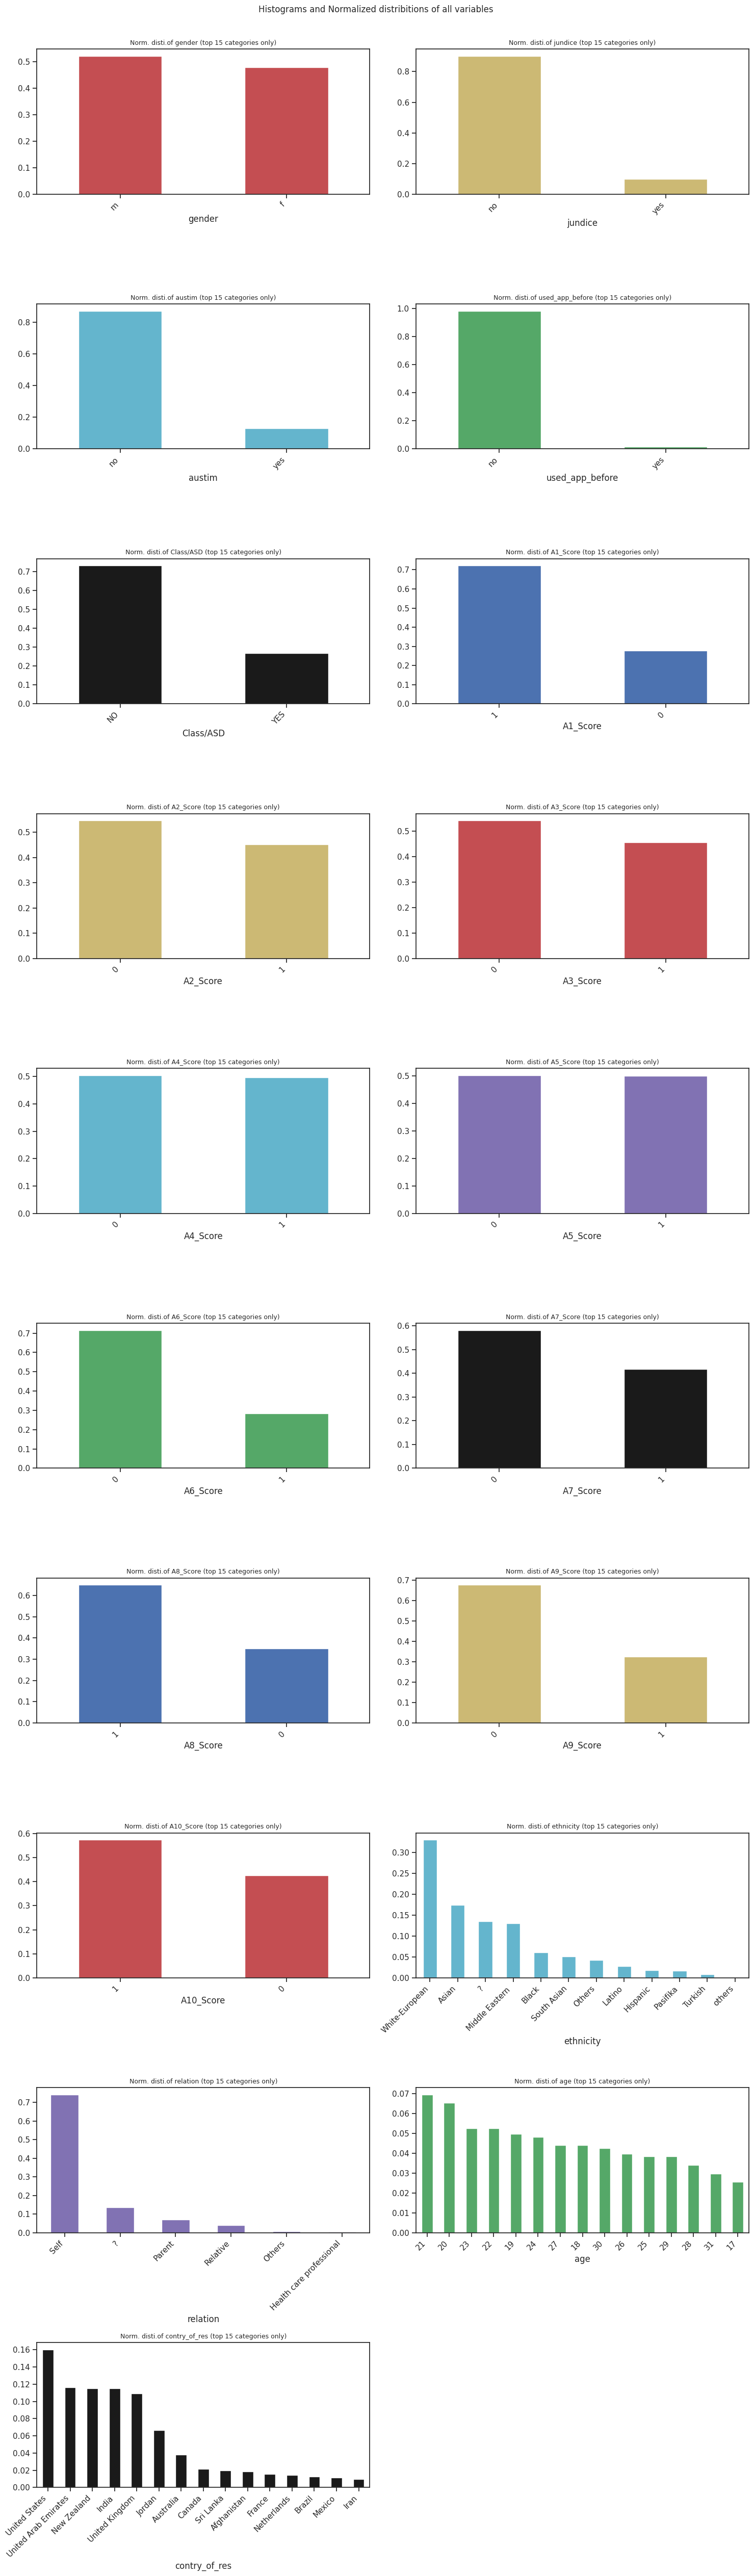

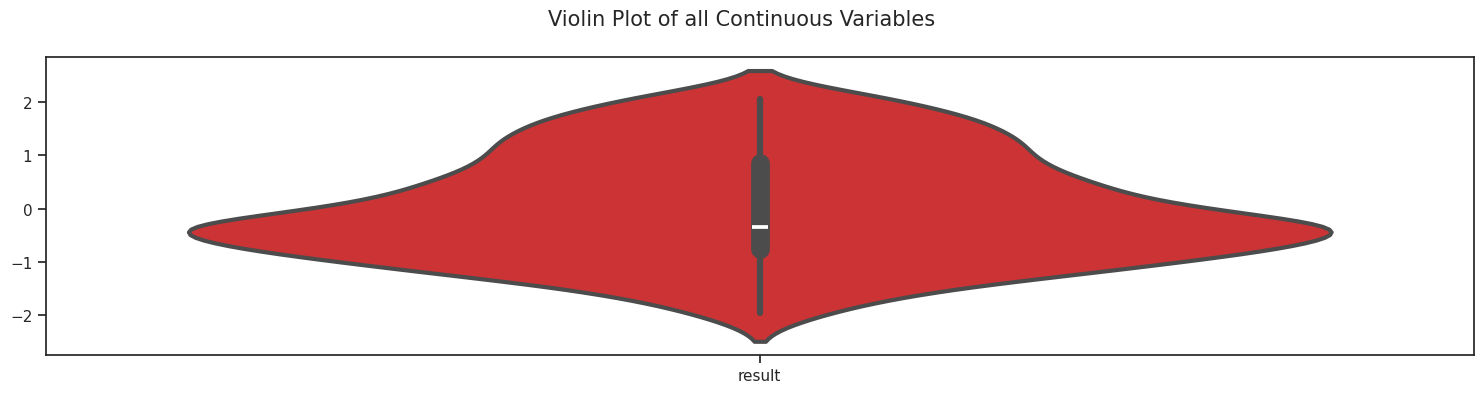

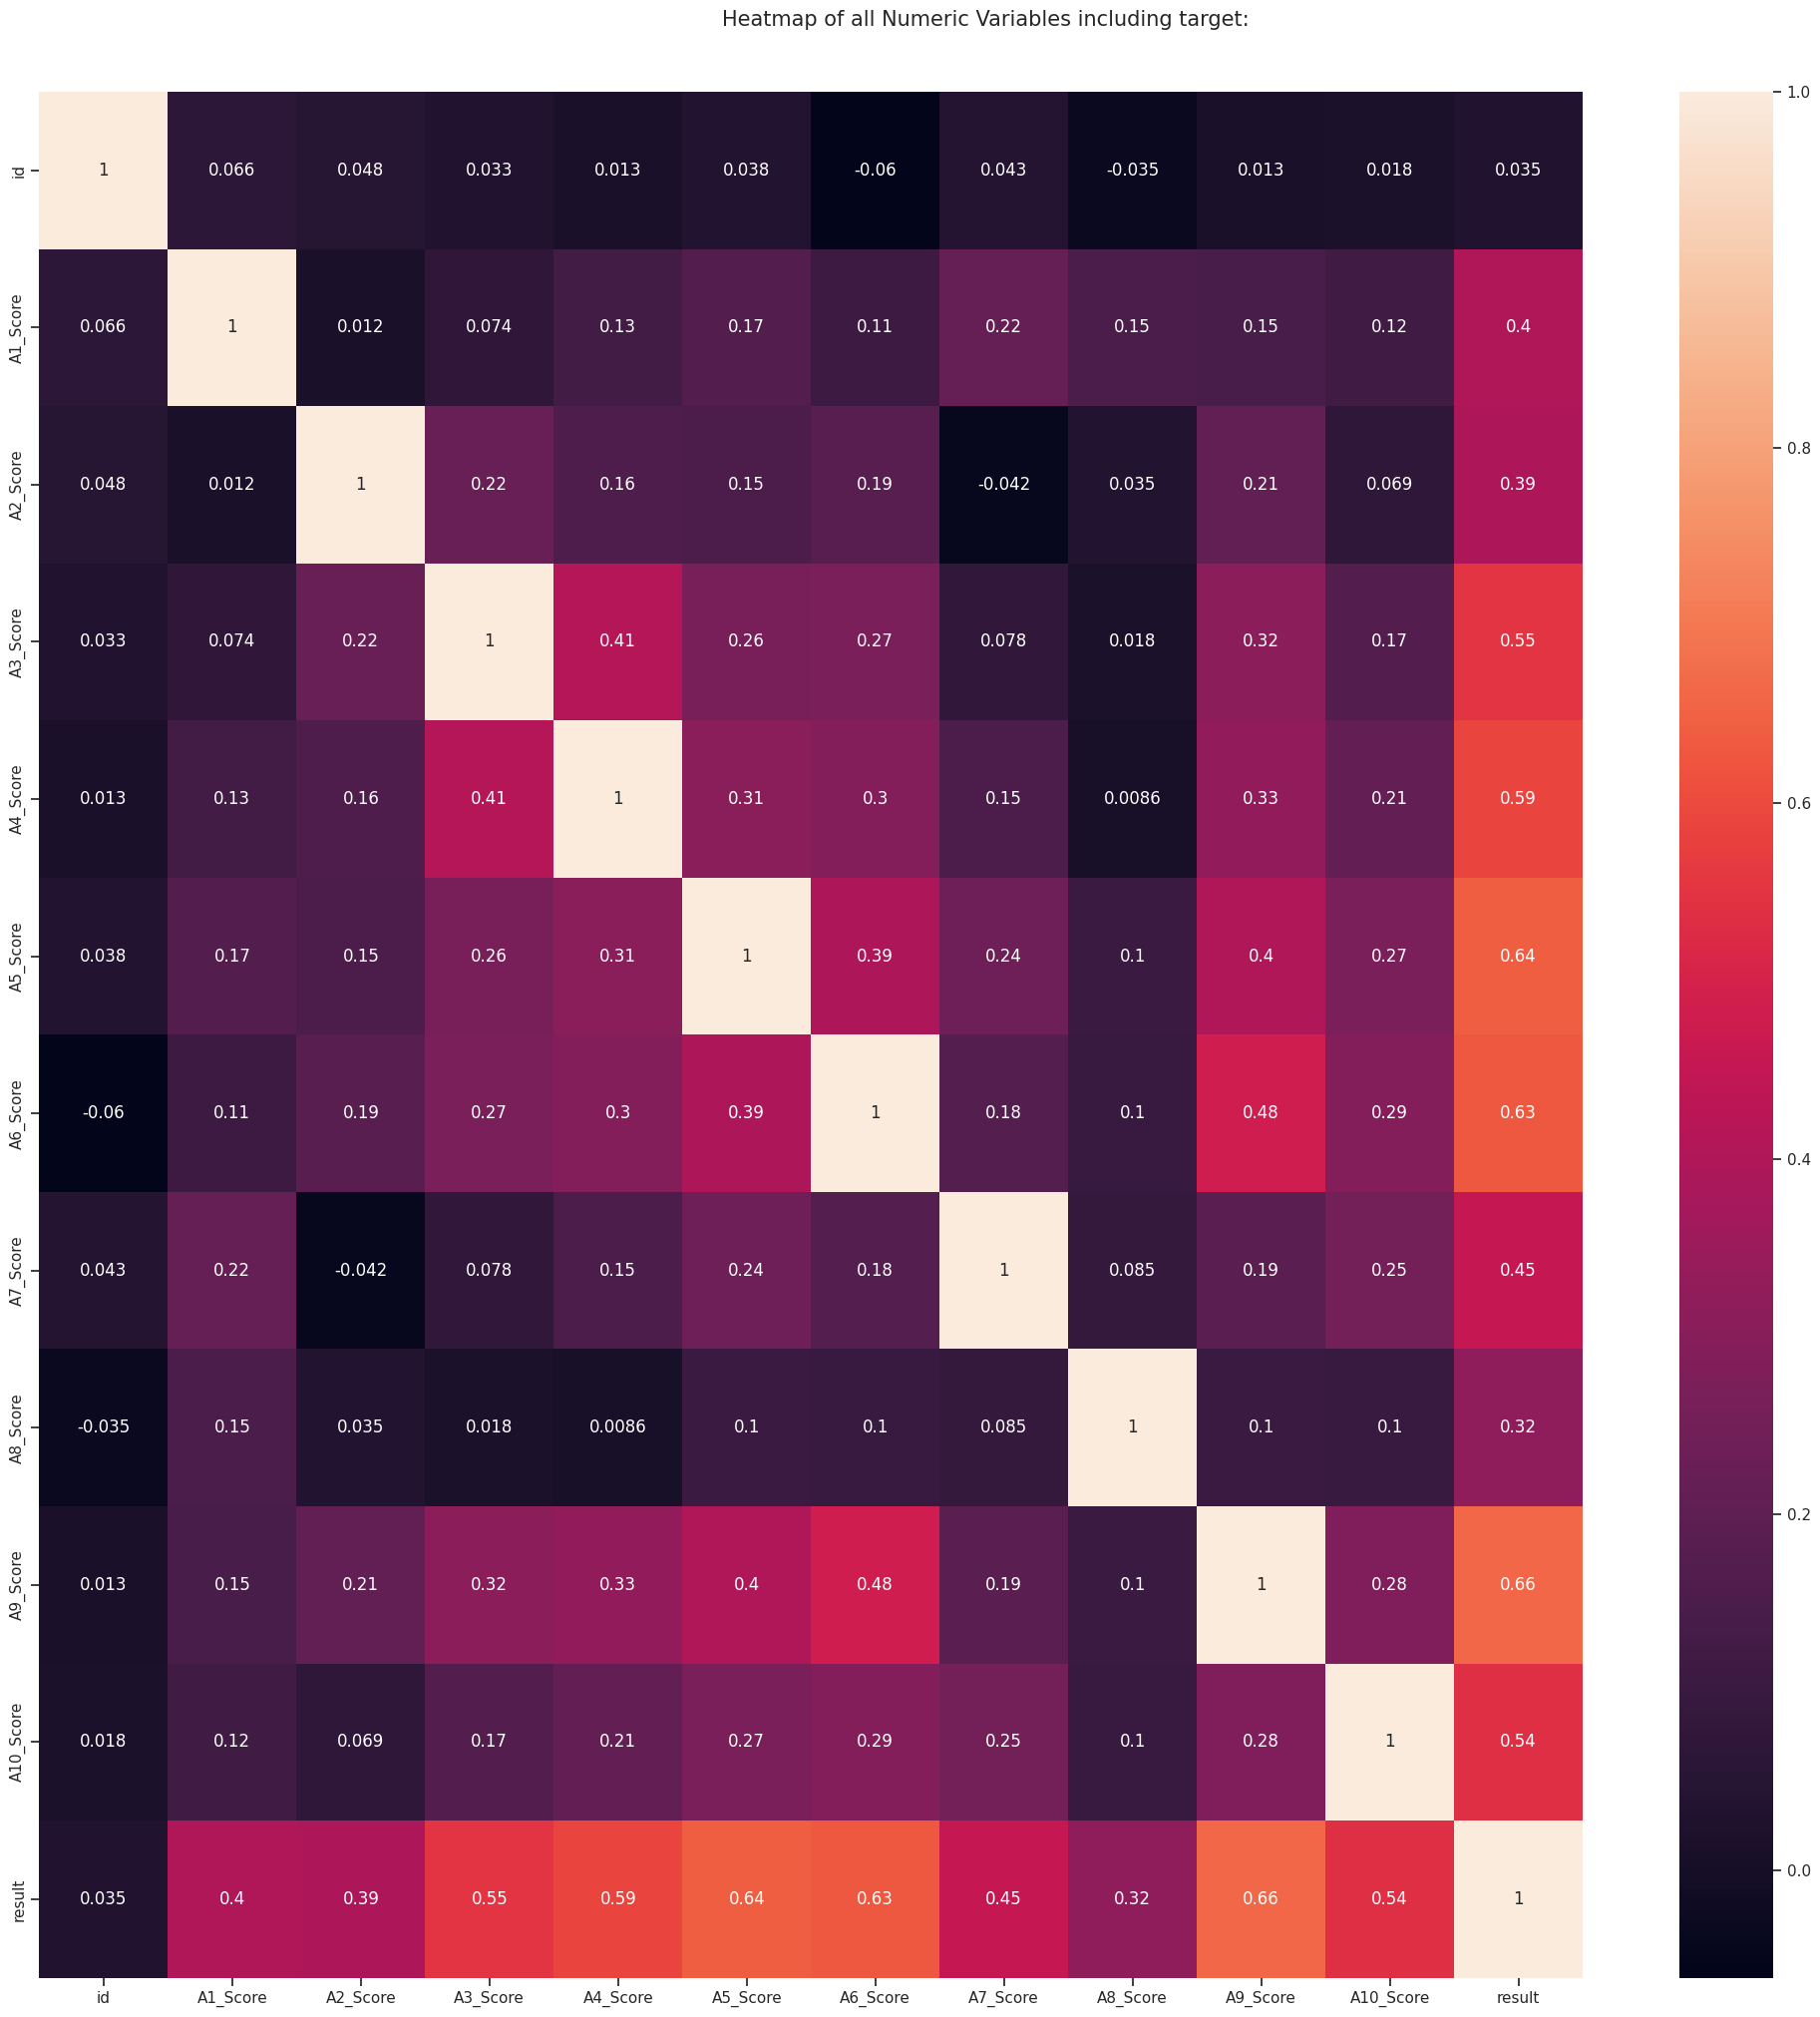

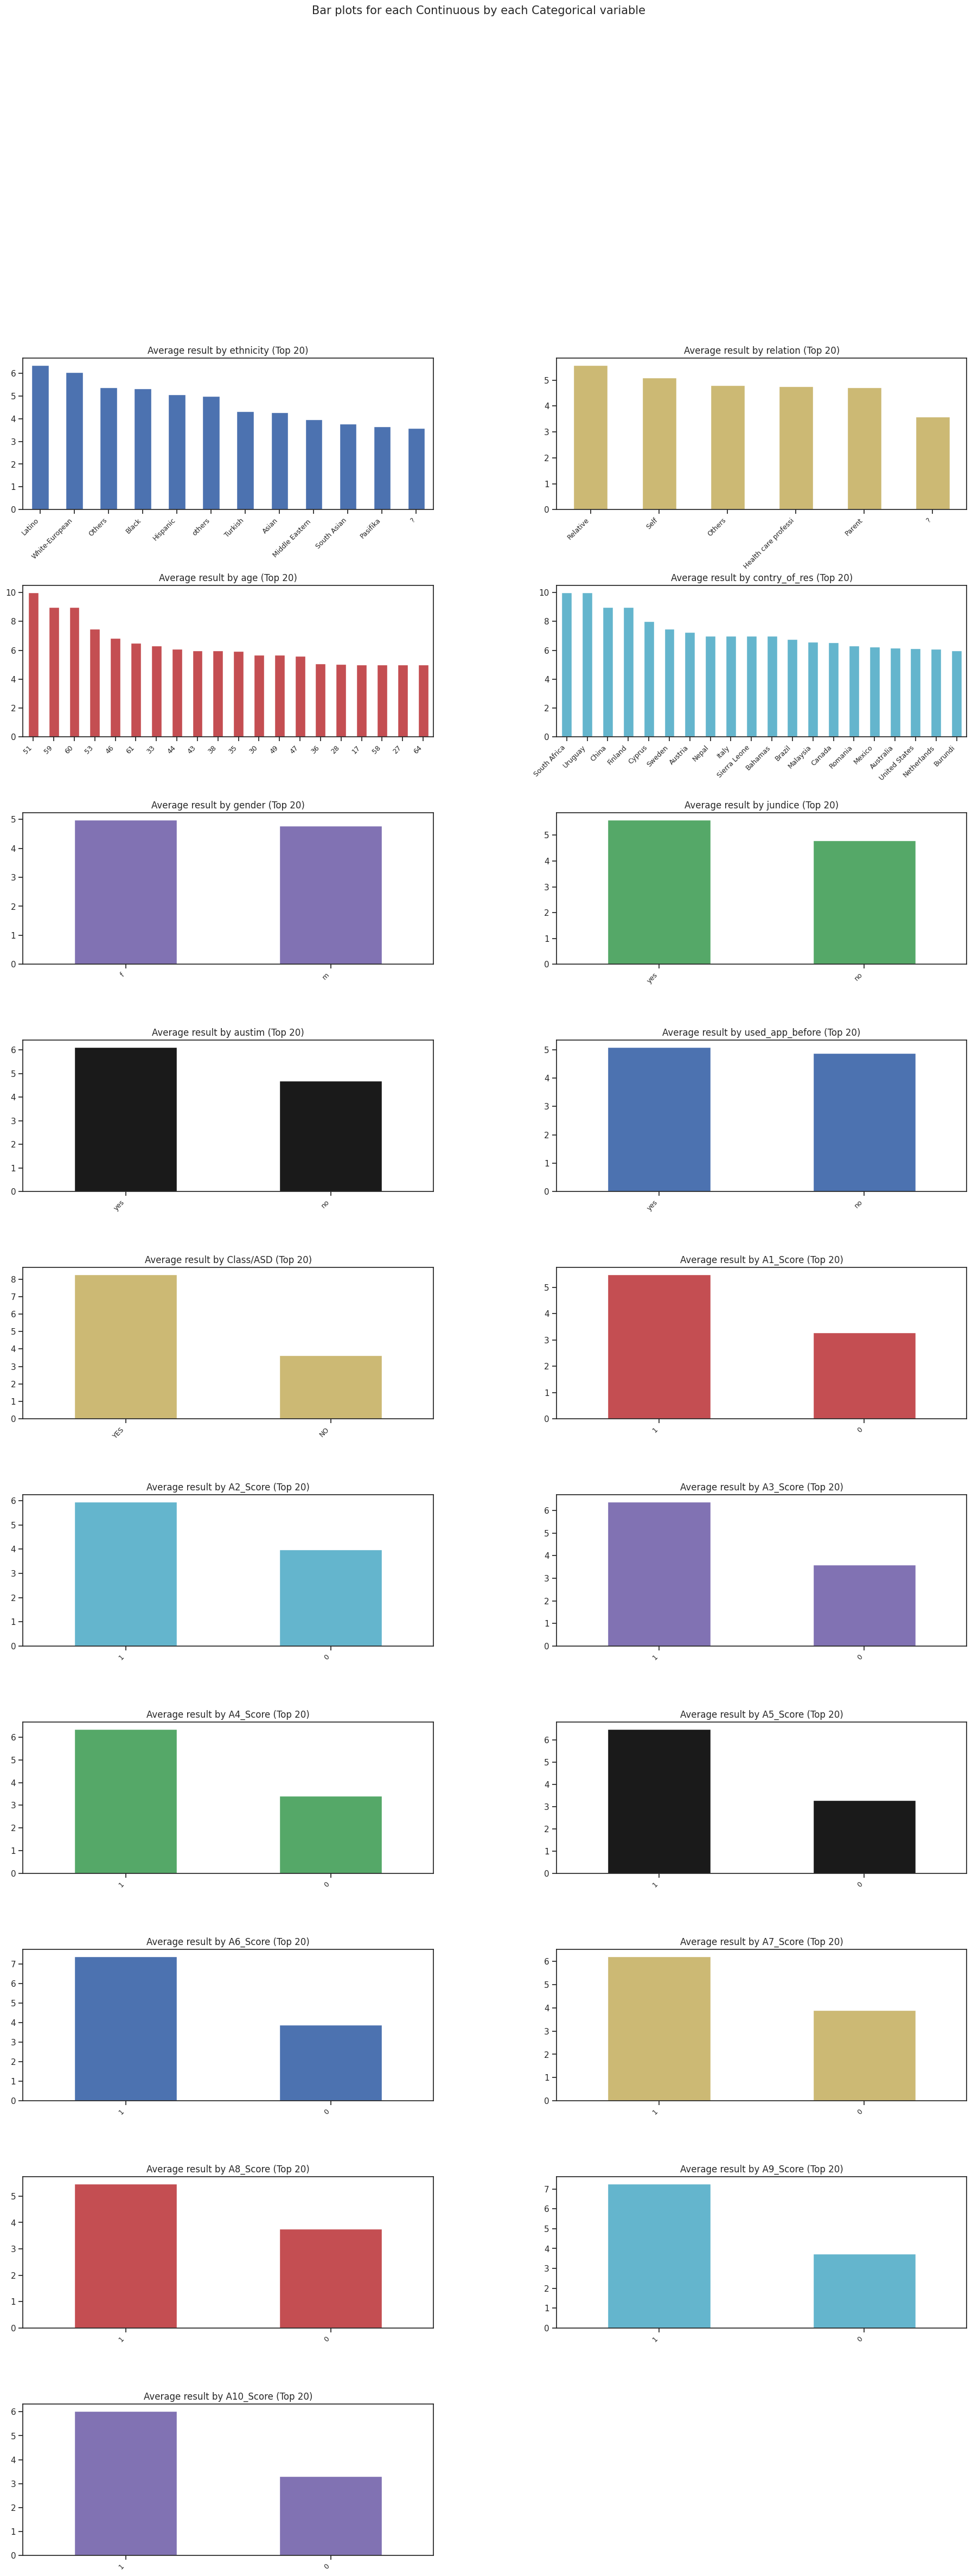

All Plots done
Time to run AutoViz = 15 seconds 

 ###################### AUTO VISUALIZATION Completed ########################


In [ ]:
from autoviz.AutoViz_Class import AutoViz_Class
import pandas as pd
AV = AutoViz_Class()
%matplotlib inline
df = pd.read_csv("Autism_Adult_Data.csv")
dfte = AV.AutoViz(df, sep=',', depVar='', dfte=None, header=0, verbose=1, lowess=False,
               chart_format='svg',max_rows_analyzed=150000,max_cols_analyzed=30, save_plot_dir=None)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               704 non-null    int64 
 1   A1_Score         704 non-null    int64 
 2   A2_Score         704 non-null    int64 
 3   A3_Score         704 non-null    int64 
 4   A4_Score         704 non-null    int64 
 5   A5_Score         704 non-null    int64 
 6   A6_Score         704 non-null    int64 
 7   A7_Score         704 non-null    int64 
 8   A8_Score         704 non-null    int64 
 9   A9_Score         704 non-null    int64 
 10  A10_Score        704 non-null    int64 
 11  age              704 non-null    object
 12  gender           704 non-null    object
 13  ethnicity        704 non-null    object
 14  jundice          704 non-null    object
 15  austim           704 non-null    object
 16  contry_of_res    704 non-null    object
 17  used_app_before  704 non-null    ob

In [ ]:
df = df.rename(mapper={"austim": "autism"})

In [ ]:
df.describe(include=['object'])

,age,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,age_desc,relation,Class/ASD
count,704,704,704,704,704,704,704,704,704,704
unique,47,2,12,2,2,67,2,1,6,2
top,21,m,White-European,no,no,United States,no,18 and more,Self,NO
freq,49,367,233,635,613,113,692,704,522,515


In [ ]:
columns_of_interest = ["age", "ethnicity"]
df[columns_of_interest].describe()

,age,ethnicity
count,704,704
unique,47,12
top,21,White-European
freq,49,233


In [ ]:
columns_of_interest = ["contry_of_res", "ethnicity",  "relation"]
for col in columns_of_interest:
  print(f"{df[col].value_counts()}")

contry_of_res
United States           113
United Arab Emirates     82
New Zealand              81
India                    81
United Kingdom           77
Jordan                   47
Australia                27
Canada                   15
Sri Lanka                14
Afghanistan              13
France                   11
Netherlands              10
Brazil                    9
Mexico                    8
Iran                      7
Russia                    7
Viet Nam                  5
Ireland                   5
Italy                     5
Malaysia                  5
Philippines               4
Germany                   4
Saudi Arabia              4
Austria                   4
Spain                     3
Romania                   3
Egypt                     3
Kazakhstan                3
Belgium                   3
Pakistan                  3
Bangladesh                3
Bahamas                   2
Sweden                    2
Argentina                 2
South Africa              2
Americ

In [ ]:
df.columns

Index(['id', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age',
       'gender', 'ethnicity', 'jundice', 'austim', 'contry_of_res',
       'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')

In [ ]:
cols = ['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'austim','jundice', 'used_app_before' ]
df[cols] = df[cols].astype(bool)

In [ ]:
df['age'] = pd.to_numeric(df['age'], errors='coerce')

In [ ]:
import numpy as np
df = df.replace(["", "?", "NA", "null"], np.nan)

In [ ]:
df.isna().sum()

,0
id,0
A1_Score,0
A2_Score,0
A3_Score,0
A4_Score,0
A5_Score,0
A6_Score,0
A7_Score,0
A8_Score,0
A9_Score,0


In [ ]:
cols = ['ethnicity', 'relation']
percentage = df[cols].isna().mean() * 100
percentage

,0
ethnicity,13.494318
relation,13.494318


In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder

# Columns to impute using KNNImputer (these are categorical)
categorical_cols_for_imputation = ['ethnicity', 'relation']

# Apply Ordinal Encoding to convert categorical strings to numerical
# NaNs are treated as NaNs by OrdinalEncoder, which is what KNNImputer expects.
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_encoded_for_imputation = df[categorical_cols_for_imputation].copy()
df_encoded_for_imputation = encoder.fit_transform(df_encoded_for_imputation)

# Initialize KNNImputer
imputer = KNNImputer(n_neighbors=2, weights="uniform")

# Impute the missing values in the encoded numerical data
X_imputed_encoded = imputer.fit_transform(df_encoded_for_imputation)

# Round the imputed float values to the nearest integer to map back to original categories
# This is crucial because inverse_transform expects integer-like values
X_imputed_encoded_rounded = np.round(X_imputed_encoded)

# Inverse transform to get the imputed categorical strings back
df_imputed_categorical = encoder.inverse_transform(X_imputed_encoded_rounded)

# Update the original DataFrame with the imputed categorical values
df.loc[:, categorical_cols_for_imputation] = df_imputed_categorical

print("Missing values in 'ethnicity', 'relation'")

Missing values in 'ethnicity', 'relation'


In [ ]:
df.isna().sum()

,0
id,0
A1_Score,0
A2_Score,0
A3_Score,0
A4_Score,0
A5_Score,0
A6_Score,0
A7_Score,0
A8_Score,0
A9_Score,0


In [ ]:
#Dropping age columns with missing values
df.dropna(subset=['age'], inplace=True)

In [ ]:
df.isna().sum()

,0
id,0
A1_Score,0
A2_Score,0
A3_Score,0
A4_Score,0
A5_Score,0
A6_Score,0
A7_Score,0
A8_Score,0
A9_Score,0


One Hot encoding

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 702 entries, 0 to 703
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               702 non-null    int64  
 1   A1_Score         702 non-null    bool   
 2   A2_Score         702 non-null    bool   
 3   A3_Score         702 non-null    bool   
 4   A4_Score         702 non-null    bool   
 5   A5_Score         702 non-null    bool   
 6   A6_Score         702 non-null    bool   
 7   A7_Score         702 non-null    bool   
 8   A8_Score         702 non-null    bool   
 9   A9_Score         702 non-null    bool   
 10  A10_Score        702 non-null    bool   
 11  age              702 non-null    float64
 12  gender           702 non-null    object 
 13  ethnicity        702 non-null    object 
 14  jundice          702 non-null    bool   
 15  austim           702 non-null    bool   
 16  contry_of_res    702 non-null    object 
 17  used_app_before  702 

In [ ]:
columns_to_one_hot = ['gender', 'ethnicity', 'contry_of_res', 'relation']
df_encoded = pd.get_dummies(df[columns_to_one_hot], drop_first=True)
df_final = pd.concat([df.drop(columns=columns_to_one_hot), df_encoded], axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 702 entries, 0 to 703
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               702 non-null    int64  
 1   A1_Score         702 non-null    bool   
 2   A2_Score         702 non-null    bool   
 3   A3_Score         702 non-null    bool   
 4   A4_Score         702 non-null    bool   
 5   A5_Score         702 non-null    bool   
 6   A6_Score         702 non-null    bool   
 7   A7_Score         702 non-null    bool   
 8   A8_Score         702 non-null    bool   
 9   A9_Score         702 non-null    bool   
 10  A10_Score        702 non-null    bool   
 11  age              702 non-null    float64
 12  gender           702 non-null    object 
 13  ethnicity        702 non-null    object 
 14  jundice          702 non-null    bool   
 15  austim           702 non-null    bool   
 16  contry_of_res    702 non-null    object 
 17  used_app_before  702 

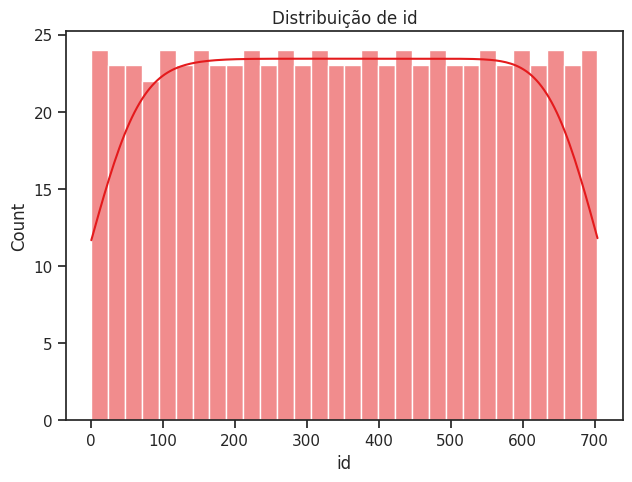

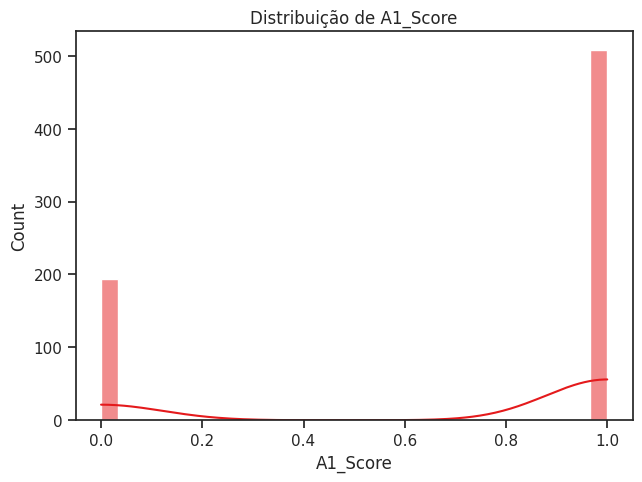

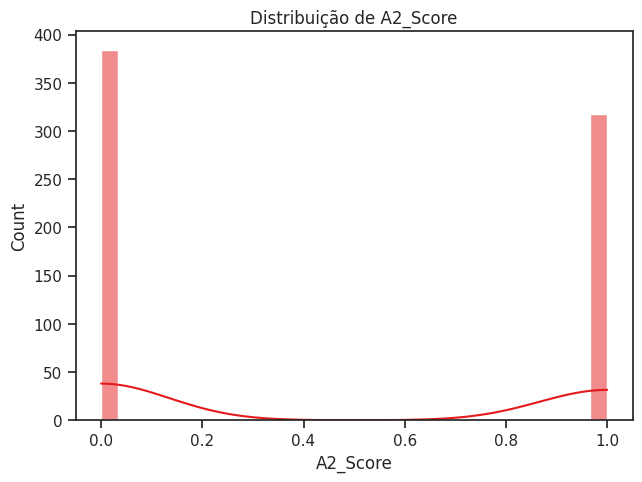

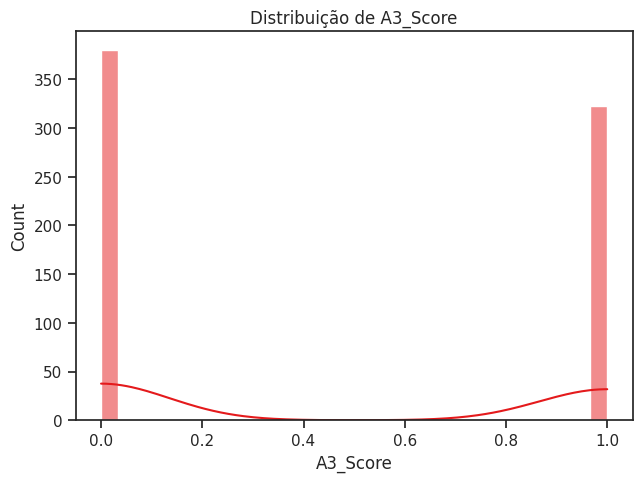

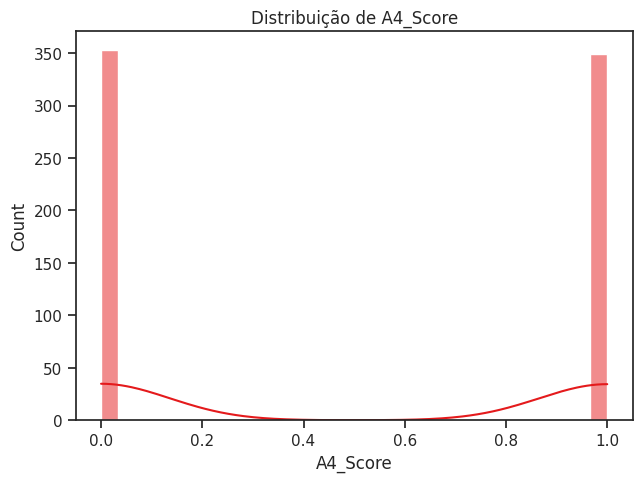

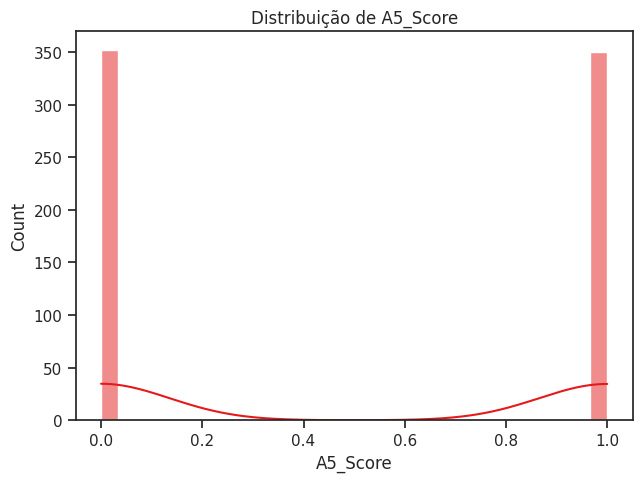

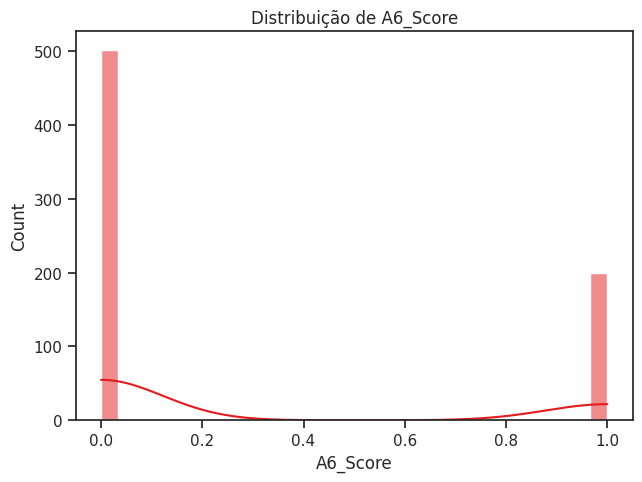

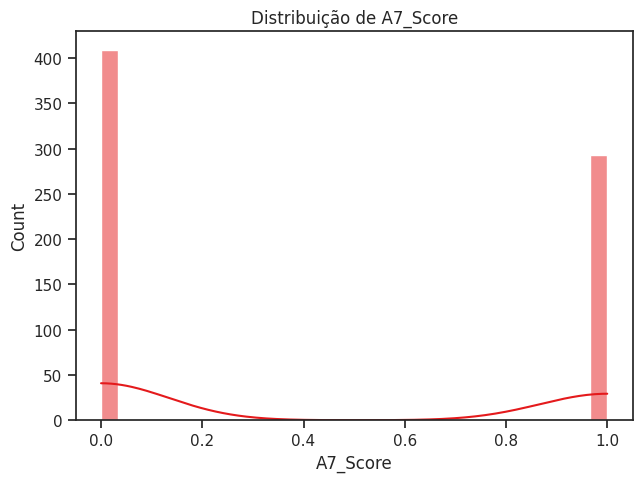

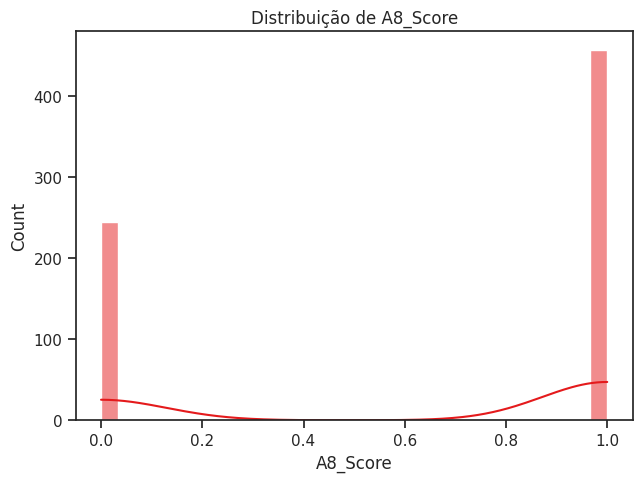

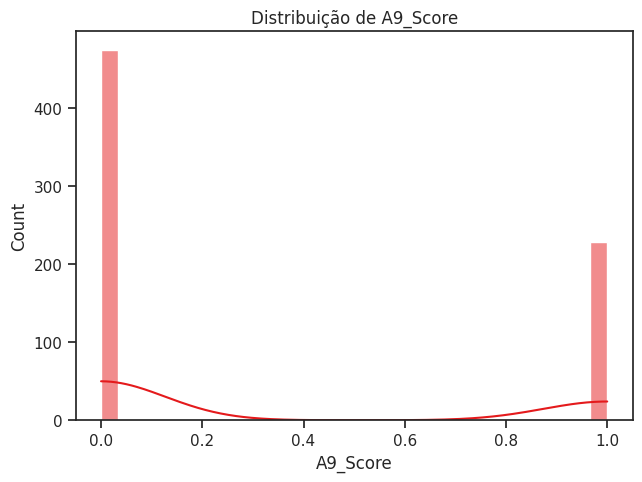

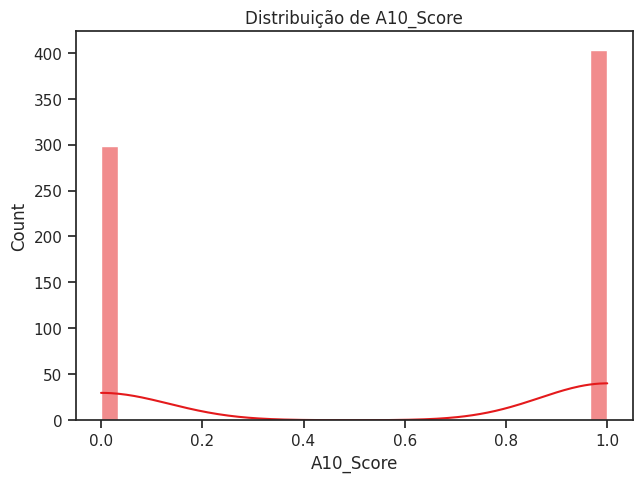

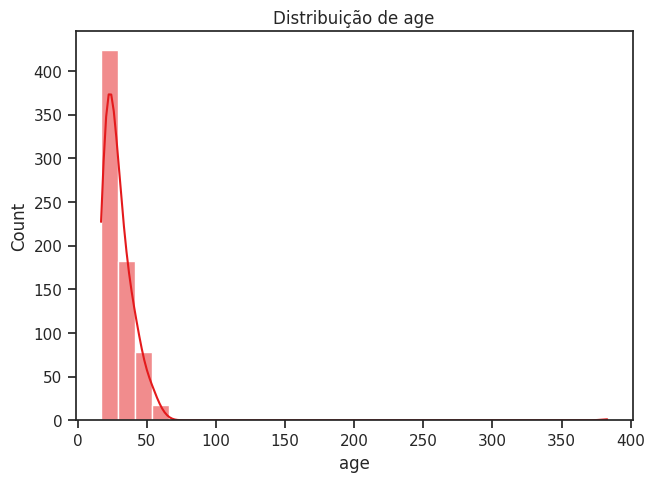

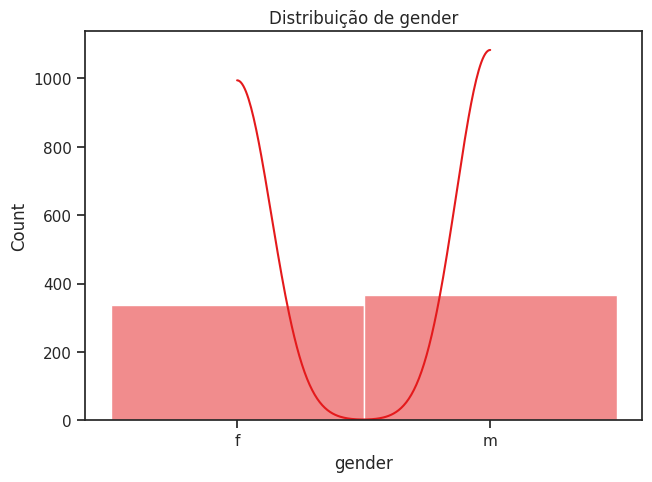

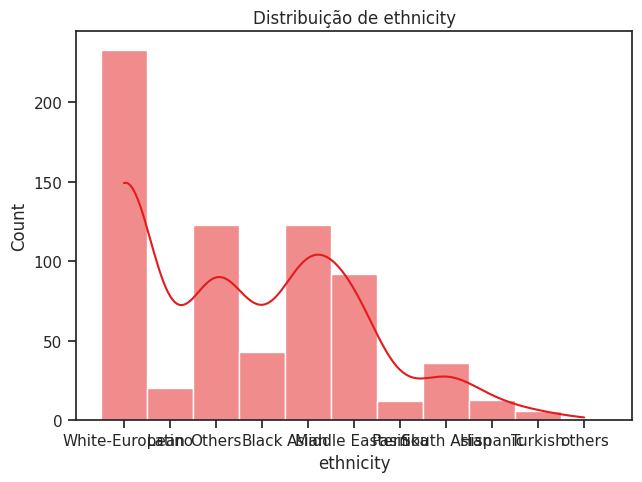

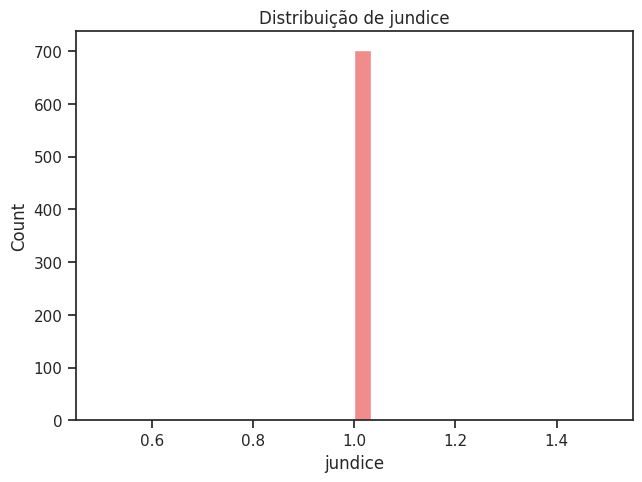

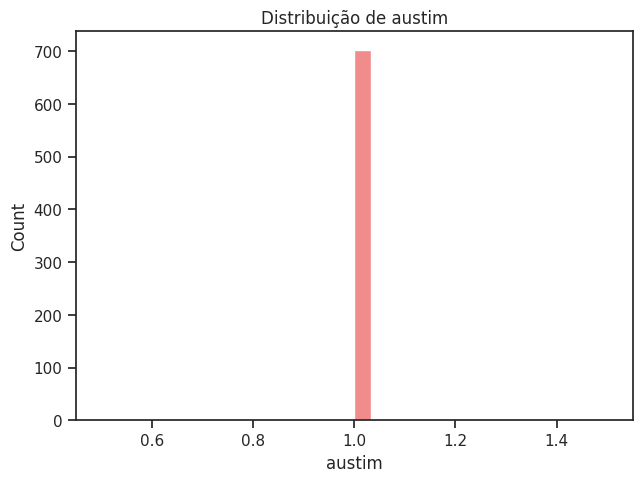

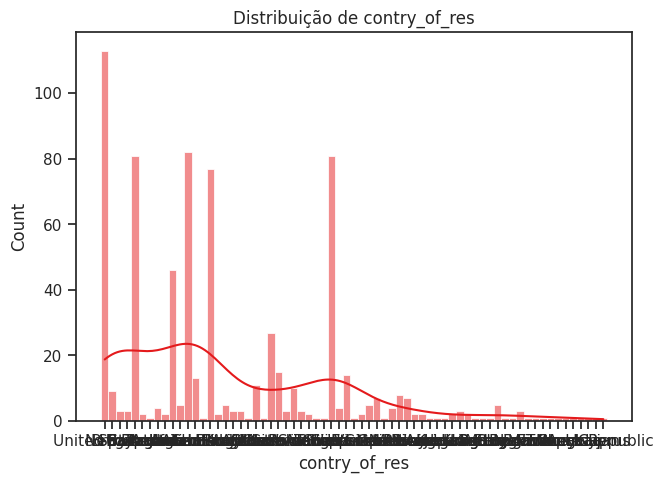

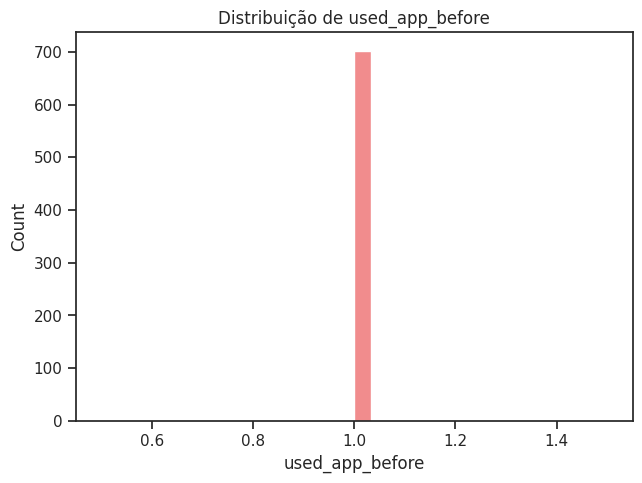

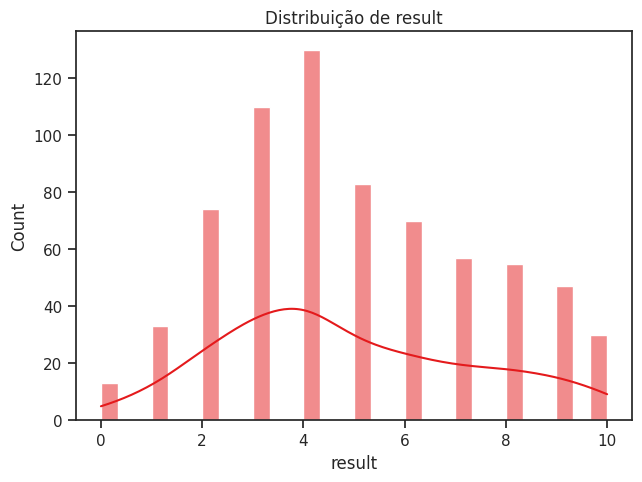

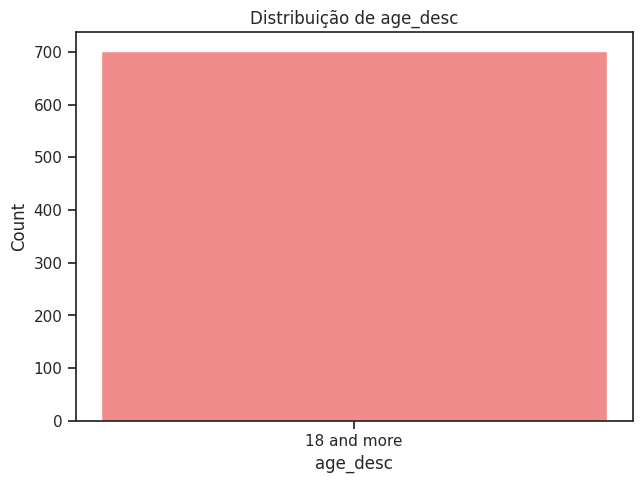

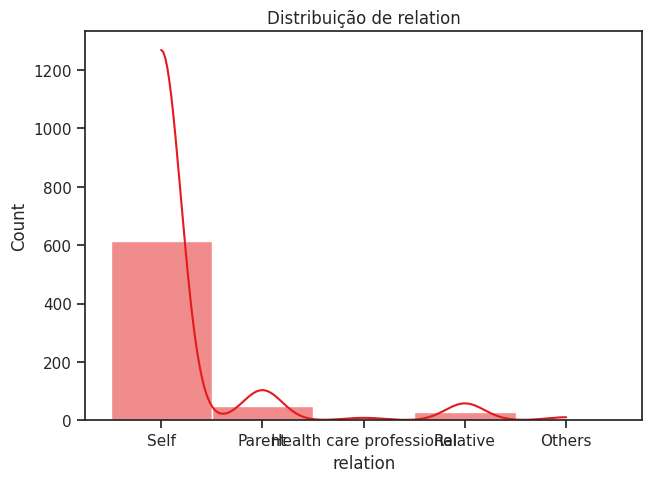

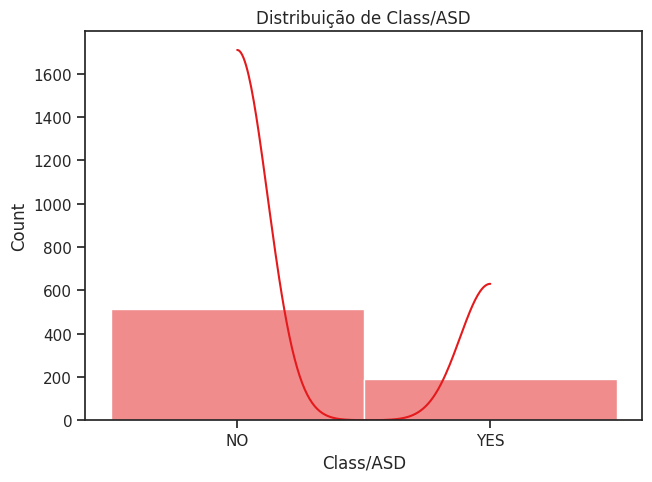

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
for coluna in df.columns:
    plt.figure()
    sns.histplot(df[coluna],kde=True,bins=30)
    plt.title(f"Distribuição de {coluna}")
    plt.show()

#Relacionamentos entre variáveis

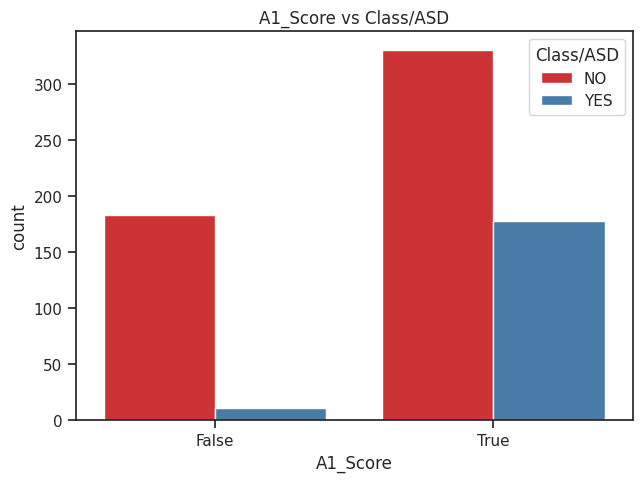

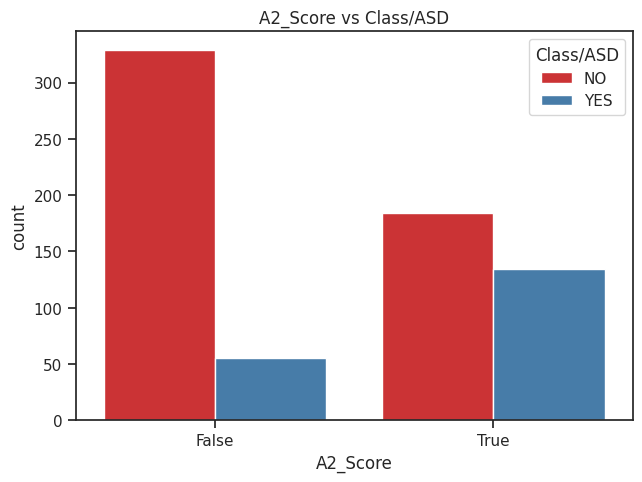

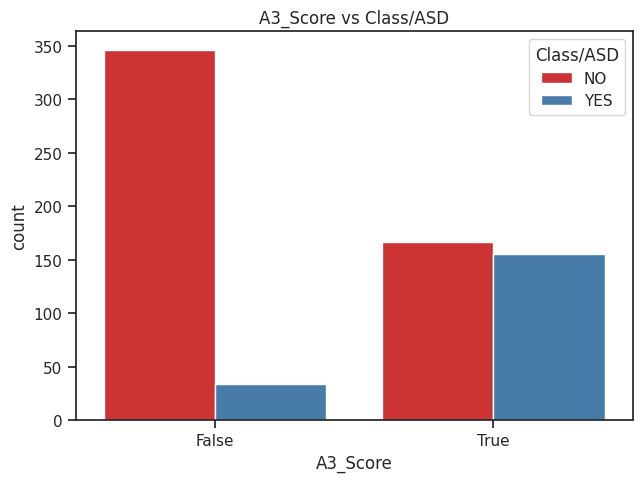

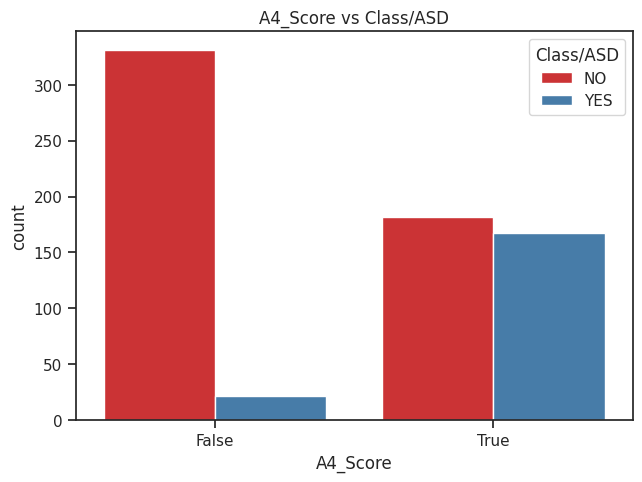

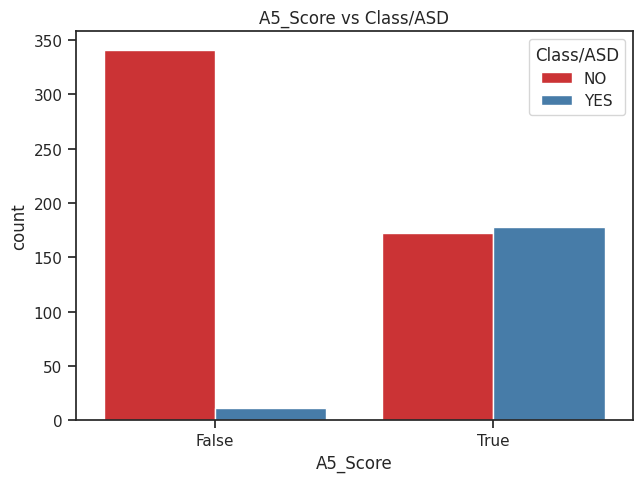

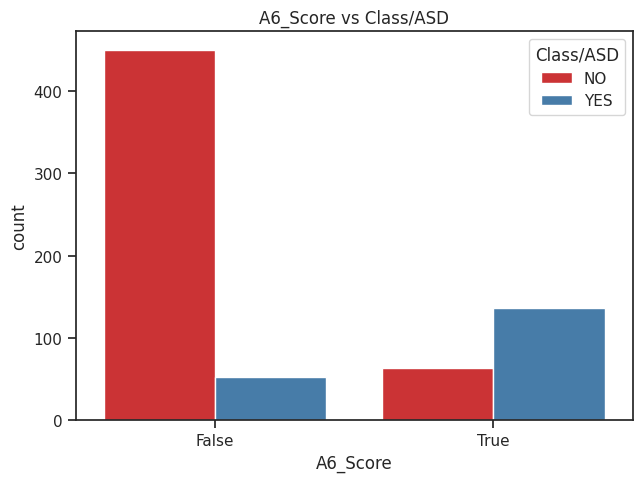

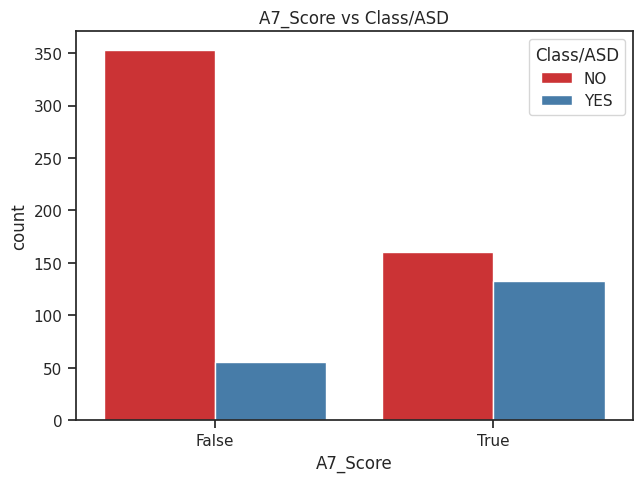

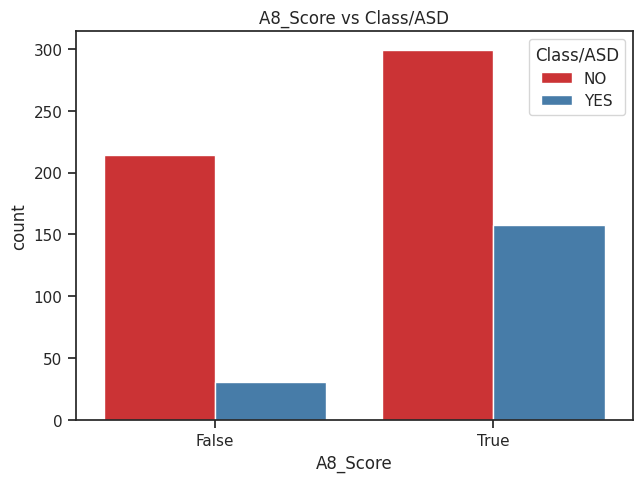

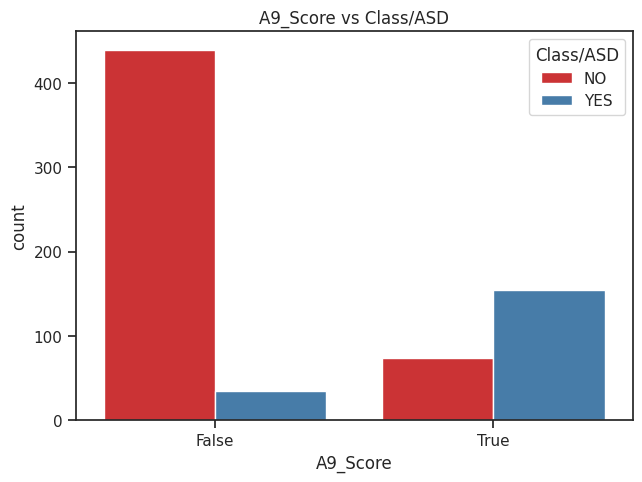

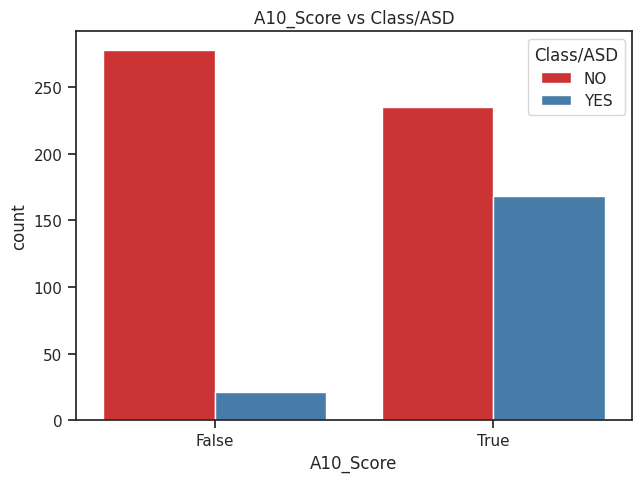

In [ ]:
import seaborn as sns
questionnaire = ['A1_Score','A2_Score', 'A3_Score','A4_Score', 'A5_Score', 'A6_Score','A7_Score','A8_Score','A9_Score','A10_Score']
for col in questionnaire:
   plt.figure()
   sns.countplot(data=df, x=col, hue='Class/ASD')
   plt.title(f'{col} vs Class/ASD')
   plt.show()

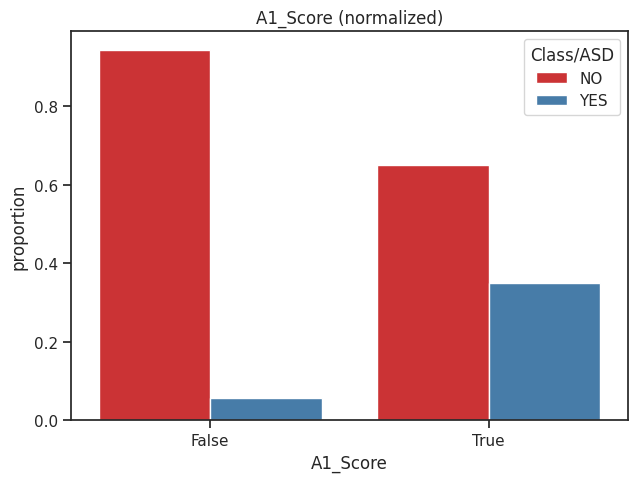

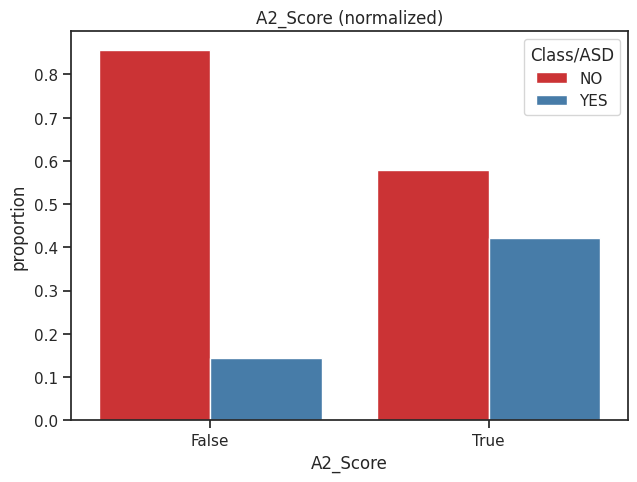

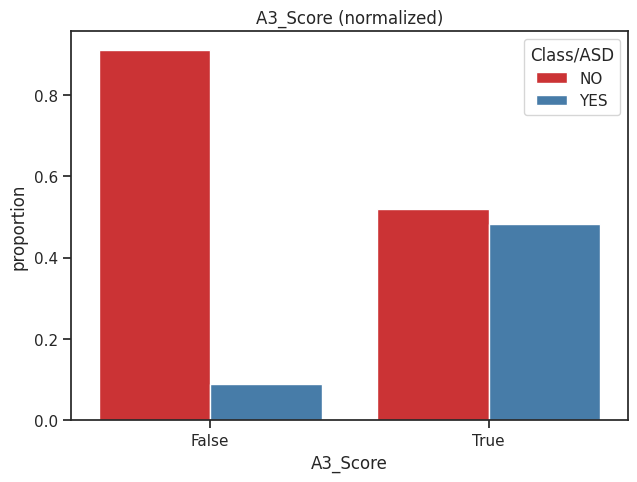

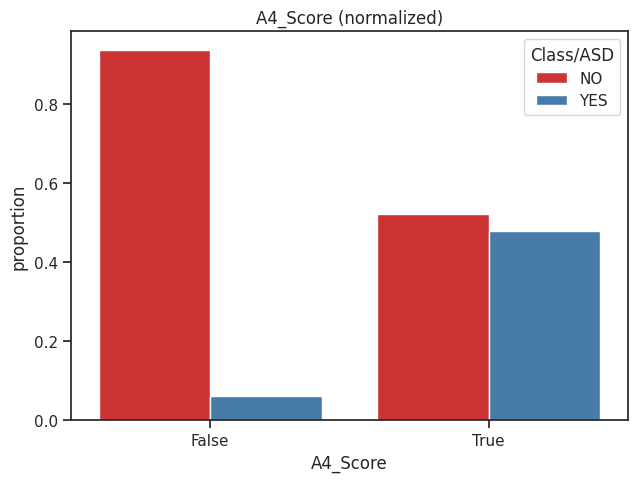

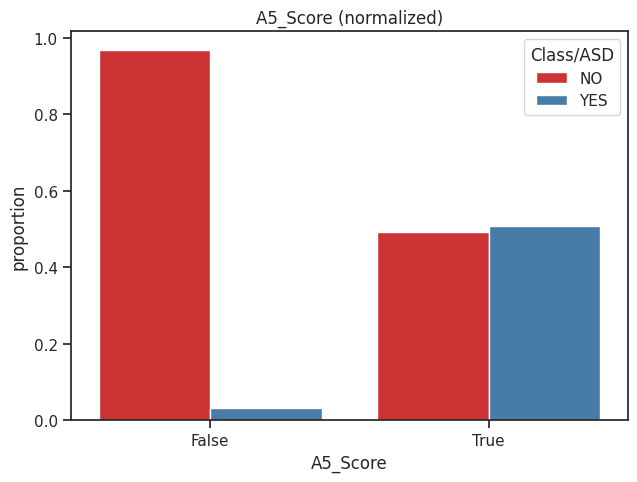

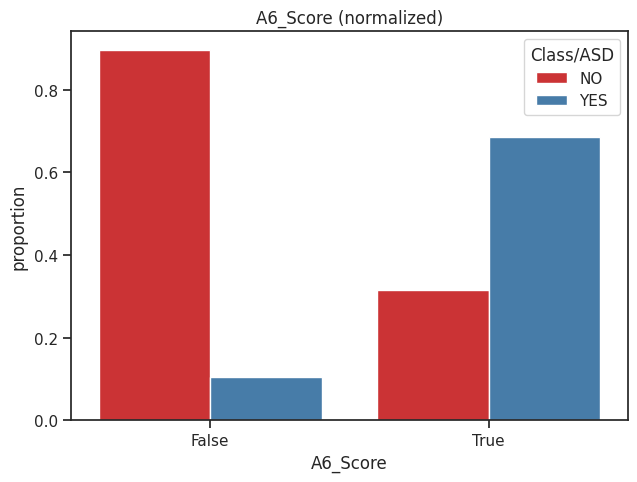

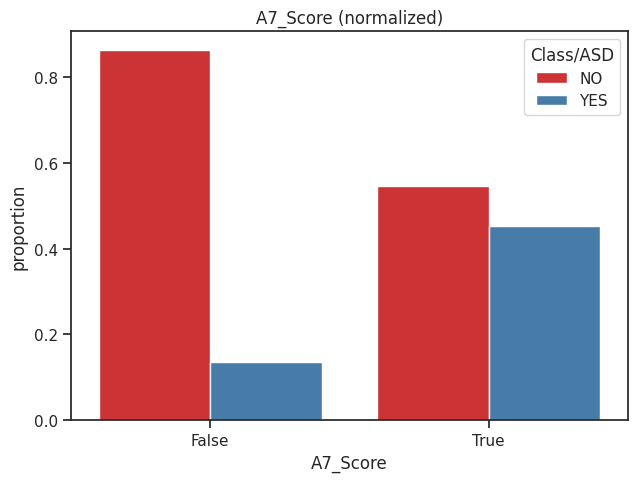

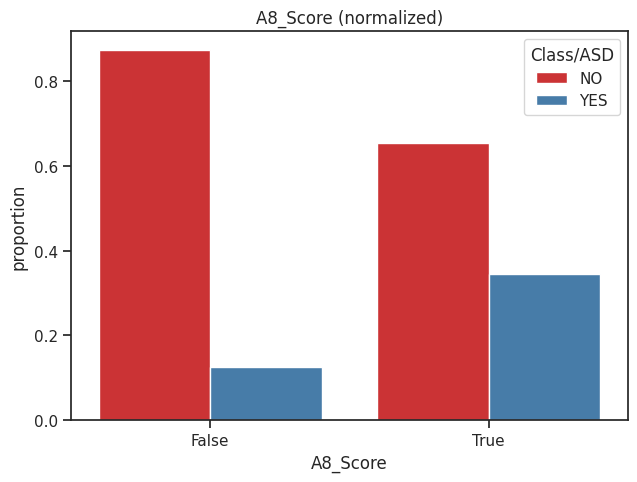

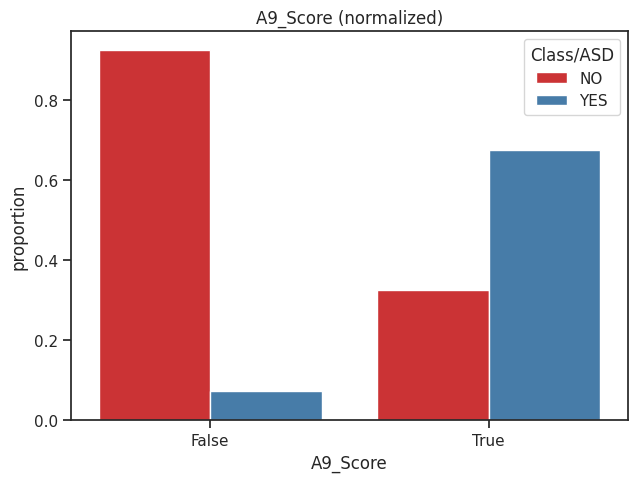

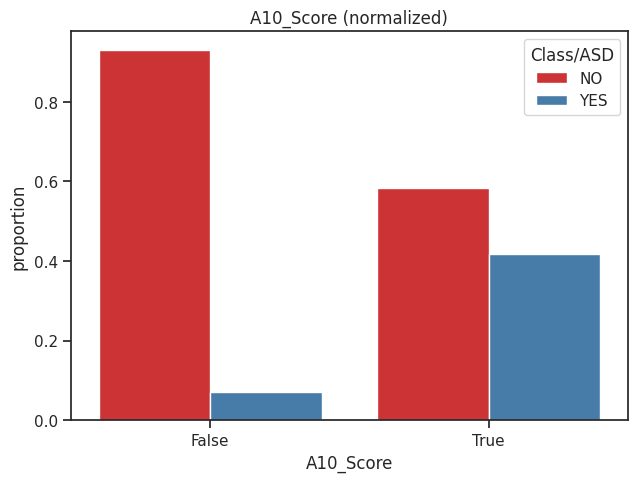

In [ ]:
for col in questionnaire:
    prop = (
        df.groupby(col)['Class/ASD']
        .value_counts(normalize=True)
        .rename('proportion')
        .reset_index()
    )

    sns.barplot(data=prop, x=col, y='proportion', hue='Class/ASD')
    plt.title(f'{col} (normalized)')
    plt.show()

In [ ]:
bool_cols = df.select_dtypes("bool")
df_numeric_class = df.copy()
df_numeric_class['Class/ASD'] = df_numeric_class['Class/ASD'].map({'NO': 0, 'YES': 1})
df_numeric_class[bool_cols.columns.tolist() + ['Class/ASD']].corr()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,jundice,austim,used_app_before,Class/ASD
A1_Score,1.000000,0.012033,0.070229,0.123898,0.170253,0.107769,0.219444,0.142301,0.142904,0.118341,NaN,NaN,NaN,0.296099
A2_Score,0.012033,1.000000,0.224762,0.159718,0.151401,0.186408,-0.044838,0.035919,0.206045,0.066231,NaN,NaN,NaN,0.312159
A3_Score,0.070229,0.224762,1.000000,0.411198,0.265631,0.267671,0.078866,0.014268,0.313894,0.168516,NaN,NaN,NaN,0.440248
A4_Score,0.123898,0.159718,0.411198,1.000000,0.307682,0.293951,0.152150,0.004794,0.326397,0.211155,NaN,NaN,NaN,0.469136
A5_Score,0.170253,0.151401,0.265631,0.307682,1.000000,0.393140,0.236398,0.102513,0.397423,0.265461,NaN,NaN,NaN,0.538055
A6_Score,0.107769,0.186408,0.267671,0.293951,0.393140,1.000000,0.176153,0.097996,0.478777,0.294771,NaN,NaN,NaN,0.591647
A7_Score,0.219444,-0.044838,0.078866,0.152150,0.236398,0.176153,1.000000,0.086408,0.190224,0.250011,NaN,NaN,NaN,0.352430
A8_Score,0.142301,0.035919,0.014268,0.004794,0.102513,0.097996,0.086408,1.000000,0.099381,0.100618,NaN,NaN,NaN,0.235557
A9_Score,0.142904,0.206045,0.313894,0.326397,0.397423,0.478777,0.190224,0.099381,1.000000,0.283660,NaN,NaN,NaN,0.635147
A10_Score,0.118341,0.066231,0.168516,0.211155,0.265461,0.294771,0.250011,0.100618,0.283660,1.000000,NaN,NaN,NaN,0.386435


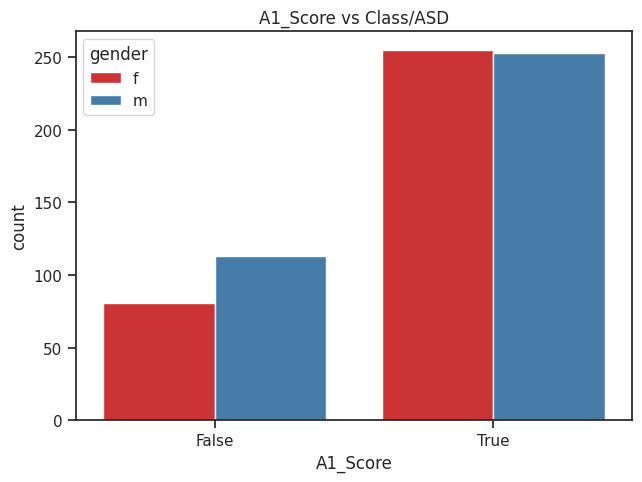

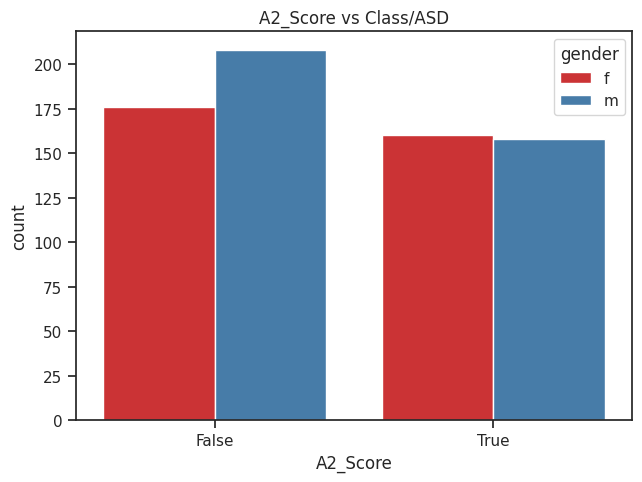

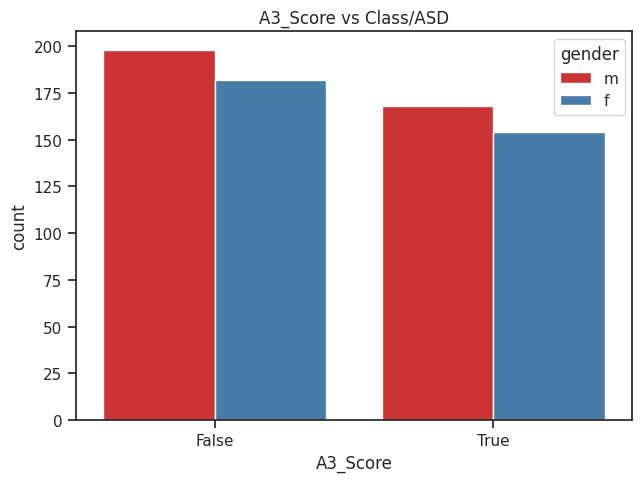

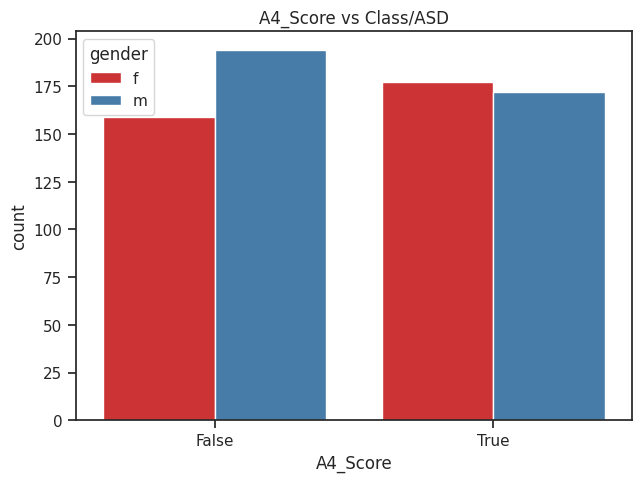

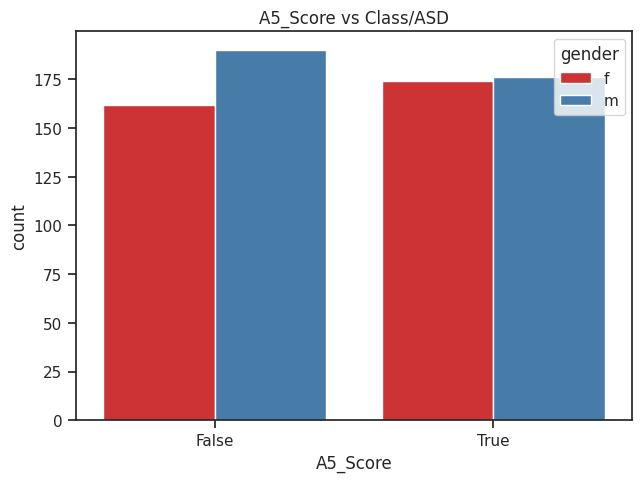

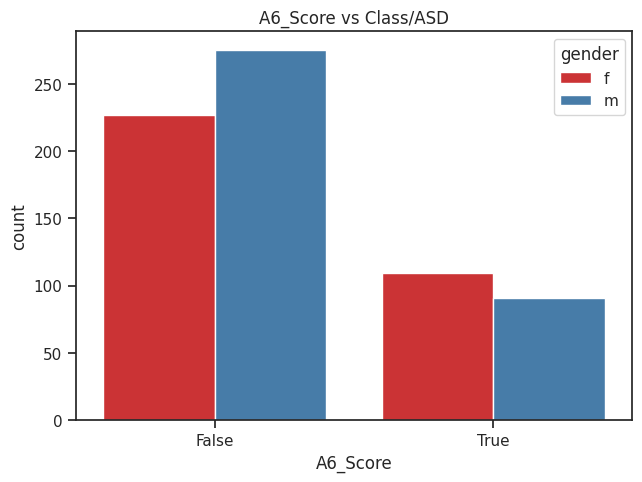

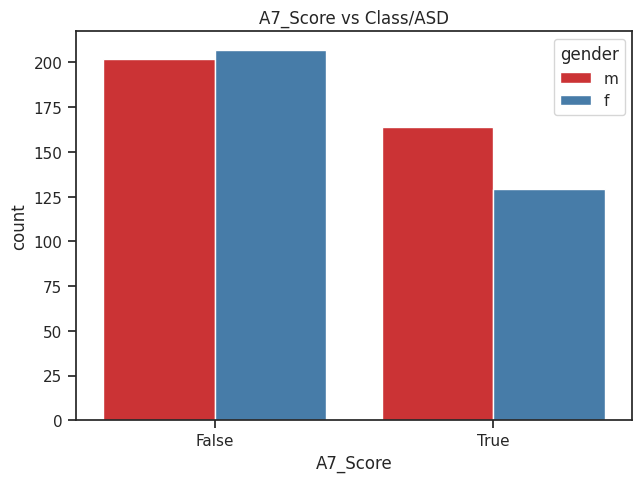

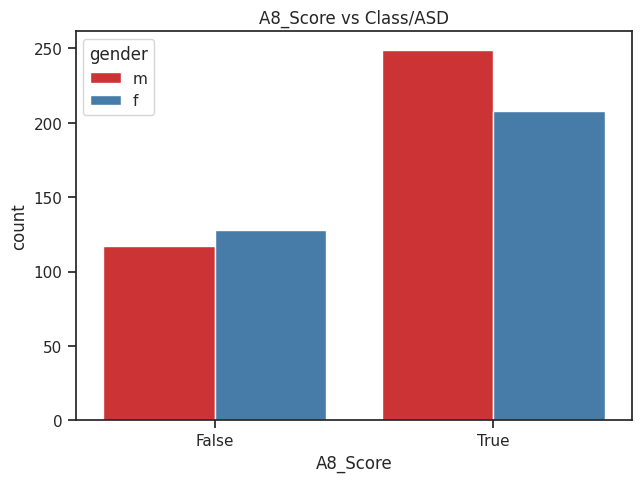

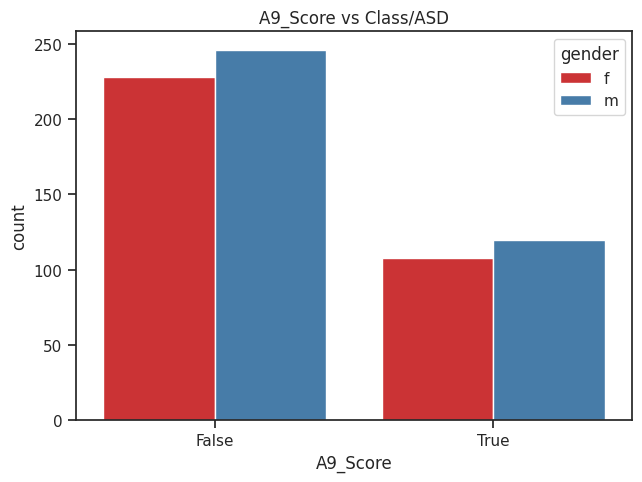

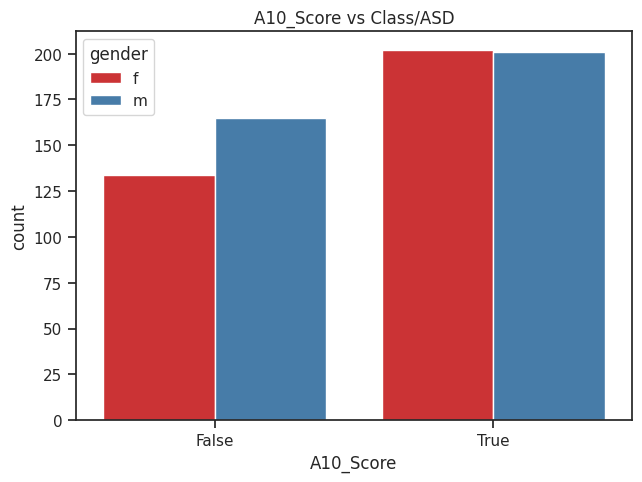

In [ ]:
import seaborn as sns
questionnaire = ['A1_Score','A2_Score', 'A3_Score','A4_Score', 'A5_Score', 'A6_Score','A7_Score','A8_Score','A9_Score','A10_Score']
for col in questionnaire:
   plt.figure()
   sns.countplot(data=df, x=col, hue='gender')
   plt.title(f'{col} vs Class/ASD')
   plt.show()

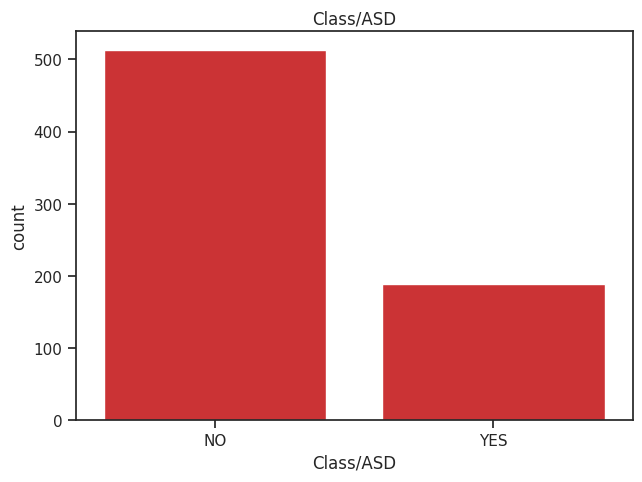

In [ ]:

plt.figure()
sns.countplot(data=df, x='Class/ASD')
plt.title(f'Class/ASD')
plt.show()

In [ ]:
df.groupby('gender')['Class/ASD'].value_counts(normalize=True).unstack()

Class/ASD,NO,YES
gender,,
f,0.693452,0.306548
m,0.765027,0.234973


In [ ]:
result = []
for col in questionnaire:
    plot = df.groupby(col)['Class/ASD'].value_counts(normalize=True).unstack()
    result.append(plot)
result

[Class/ASD     NO        YES  
 A1_Score                     
 False      0.943299  0.056701
 True       0.649606  0.350394,
 Class/ASD     NO        YES  
 A2_Score                     
 False      0.856771  0.143229
 True       0.578616  0.421384,
 Class/ASD     NO        YES  
 A3_Score                     
 False      0.910526  0.089474
 True       0.518634  0.481366,
 Class/ASD     NO        YES  
 A4_Score                     
 False      0.937677  0.062323
 True       0.521490  0.478510,
 Class/ASD     NO        YES  
 A5_Score                     
 False      0.968750  0.031250
 True       0.491429  0.508571,
 Class/ASD     NO        YES  
 A6_Score                     
 False      0.896414  0.103586
 True       0.315000  0.685000,
 Class/ASD     NO        YES  
 A7_Score                     
 False      0.863081  0.136919
 True       0.546075  0.453925,
 Class/ASD     NO        YES  
 A8_Score                     
 False      0.873469  0.126531
 True       0.654267  0.345733,


<Axes: xlabel='Class/ASD', ylabel='age'>

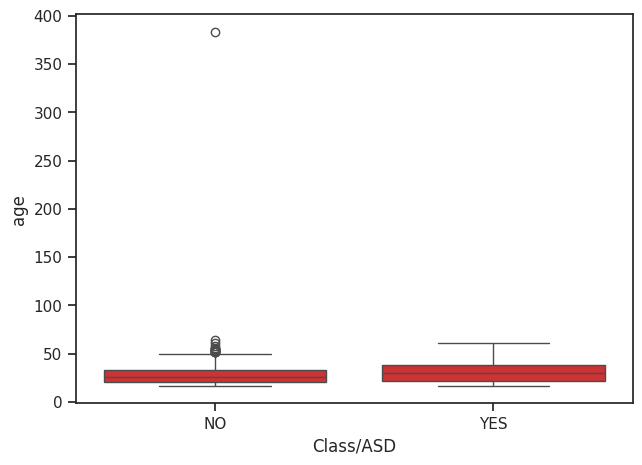

In [ ]:
import seaborn as sns
sns.boxplot(data=df, x='Class/ASD', y='age')

<Axes: xlabel='gender', ylabel='age'>

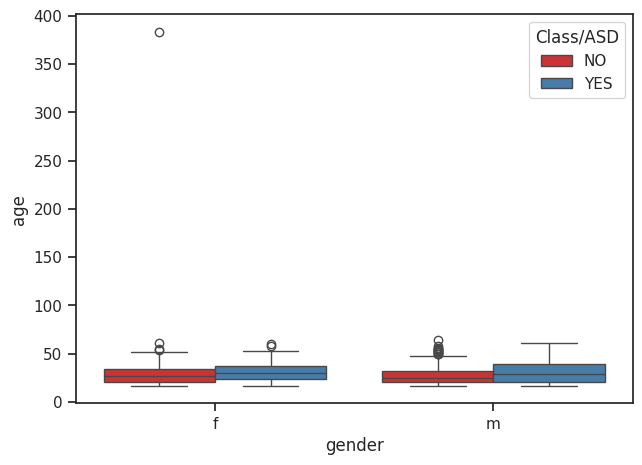

In [ ]:
sns.boxplot(data=df, x='gender', y='age', hue='Class/ASD')

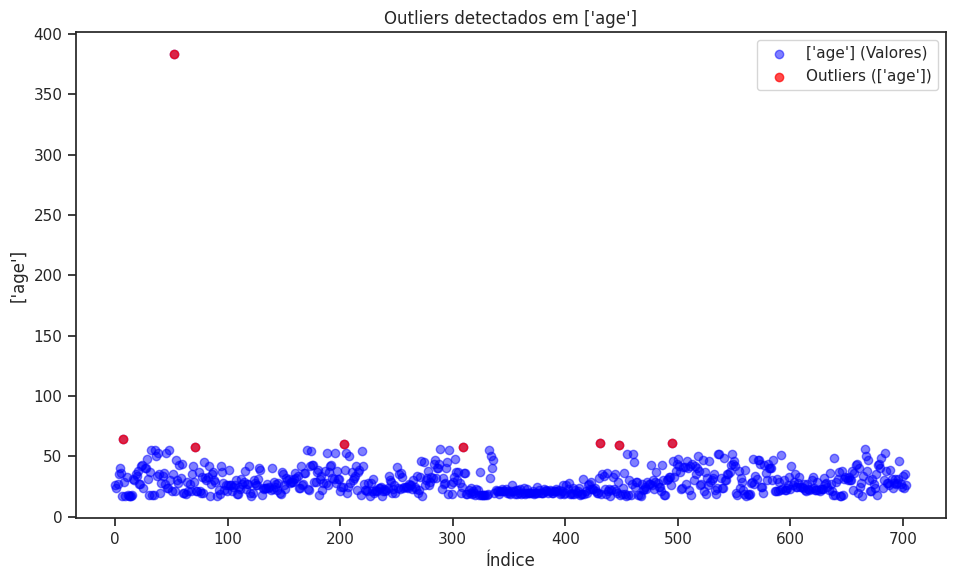

In [ ]:
#Análise de outliers na coluna de idade
coluna = ['age']
Q1 = df[coluna].quantile(0.25)
Q3 = df[coluna].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[coluna] < lower_bound) | (df[coluna] > upper_bound)]
#print(f"\nOutliers detectados em {coluna}:")
#print(outliers)

plt.figure(figsize=(10, 6))

# Plotando todos os pontos
plt.scatter(df.index, df[coluna], label=f'{coluna} (Valores)', color='blue', alpha=0.5)

# Plotando os outliers em vermelho
plt.scatter(outliers.index, outliers[coluna], label=f'Outliers ({coluna})', color='red', alpha=0.7)

# Adicionando título e rótulos
plt.title(f"Outliers detectados em {coluna}")
plt.xlabel('Índice')
plt.ylabel(f'{coluna}')

# Exibindo legenda
plt.legend()

# Exibindo o gráfico
plt.show()

In [ ]:
df['age'].max()

383.0

In [ ]:
max_age = df['age'].max()
df = df[df['age'] != max_age]
print(f"Rows with age = {max_age} have been removed. New DataFrame shape: {df.shape}")

Rows with age = 383.0 have been removed. New DataFrame shape: (701, 22)


In [ ]:
df['age'].max()

64.0

In [ ]:
max_age = df_final['age'].max()
df_final = df_final[df_final['age'] != max_age]
print(f"Rows with age = {max_age} have been removed. New DataFrame shape: {df_final.shape}")

Rows with age = 383.0 have been removed. New DataFrame shape: (701, 99)


In [ ]:
df_final.to_csv('df_final.csv', index=False)
print('df_final.csv saved successfully!')

df_final.csv saved successfully!


In [ ]:
df.to_csv('df.csv', index=False)
print('df.csv saved successfully!')

df.csv saved successfully!
